In [1]:
%load_ext autoreload 
%autoreload 2

# Multislice ptychography example

Data from the paper by [Nguyen et al. (2025)](https://www.science.org/doi/full/10.1126/science.adl2029).

The reconstruction methods used here are discussed in more detail in [our paper](https://arxiv.org/abs/2511.07795).

Arthur McCray
Last updated: April 22, 2026

In [ ]:
from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.ml import CNN2d, OptimizerParams, SchedulerParams
from quantem.core.visualization import show_2d, ShowParams, linescan
from quantem.core.datastructures import Dataset4dstem
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
    PtychographyDatasetRaster,
    PtychoObjConstraintParams,
)
import skimage
from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter

print(f"quantEM version: {em.__version__}")

GPU_ID = 0
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
Using GPU cuda:3


## Import and visualize data

Start by defining the experimental constants we will rely on throughout this workflow.

Even when partial metadata exists in the microscope file, it is good practice to explicitly set critical values in the notebook so reconstruction settings are auditable and reproducible:

- probe energy
- probe semi-convergence angle
- estimated defocus
- scan step size

In [3]:
PROBE_ENERGY = 80e3
PROBE_SEMIANGLE = 24.9 
PROBE_DEFOCUS = 0 
SCAN_STEP_SIZE = 0.4290 # Angstrom

NUM_PROBES = 6
NUM_SLICES = 16
SLICE_THICKNESS = 1

probe_params = {
    "energy" : PROBE_ENERGY,
    "defocus" : PROBE_DEFOCUS,
    "semiangle_cutoff" : PROBE_SEMIANGLE, 
}

In [4]:
import os 

## from ptyrad 
def load_raw(file_path, shape, dtype=np.float32, offset=0, gap=1024):
    # shape = (N, height, width)
    # np.fromfile with a custom dtype is faster than np.read + np.frombuffer.
    # This implementation is roughly 2x faster (10 s vs 20 s) than load_hdf5 for a 1 GB EMPAD dataset.
    # Some custom-processed EMPAD2 raws may not include inter-frame gaps.
    N, height, width = shape

    # Verify file size before parsing.
    expected_size = offset + N * (height * width * dtype().itemsize + gap)
    actual_size = os.path.getsize(file_path)

    if actual_size != expected_size:
        raise ValueError(f"Mismatch in expected ({expected_size} bytes = offset + N * (height * width * 4 + gap)) vs. actual ({actual_size} bytes) file size! Check your loading configurations!")
    
    # Define a custom dtype containing both data and gap regions.
    custom_dtype = np.dtype([
        ('data', dtype, (height, width)),
        ('gap', np.uint8, gap)  # uint8 -> 1 byte per gap element
    ])

    # Read the full file using the custom dtype.
    with open(file_path, 'rb') as f:
        f.seek(offset)
        raw_data = np.fromfile(f, dtype=custom_dtype, count=N)

    # Extract only the `data` field (ignore gap bytes).
    data = raw_data['data']
    print("Success! Loaded .raw file path =", file_path)
    print("Imported .raw data shape =", data.shape)
    print("Imported .raw data type =", data.dtype)
    return data
    
    
fdata = Path("~/data/example_data/Panel_g-h_Themis/scan_x128_y128.raw").expanduser()
data_array = load_raw(fdata, shape=(128*128,128,128), dtype=np.float32)
data_array = data_array.reshape((128,128,128,128))
data_array = np.transpose(data_array, (0,1,3,2))

Success! Loaded .raw file path = /home/amccray/data/example_data/Panel_g-h_Themis/scan_x128_y128.raw
Imported .raw data shape = (16384, 128, 128)
Imported .raw data type = float32


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'tBL_WSe2_dp_mean'}>)

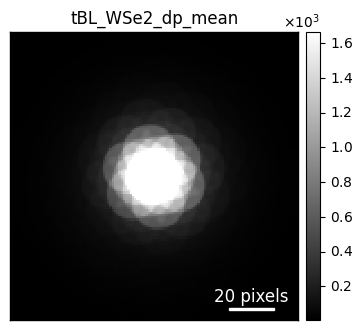

In [5]:
dset = Dataset4dstem.from_array(
    data_array,
    name='tBL_WSe2',
    sampling=(SCAN_STEP_SIZE, SCAN_STEP_SIZE, 1, 1),
    units=("A", "A", "pixels", "pixels")
)
dset.get_dp_mean()
dset.dp_mean.show(upper_quantile=0.97, cbar=True)

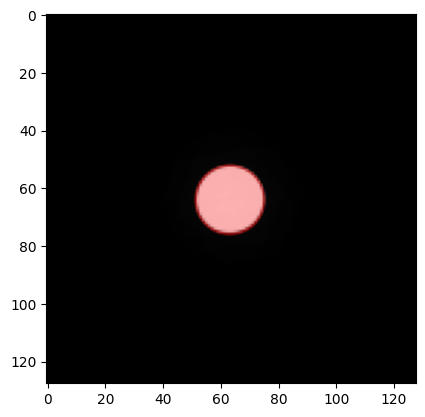

quantem Dataset named 'tBL_WSe2'
  shape: (128, 128, 128, 128)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [0.429      0.429      2.07961127 2.07961127]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'


In [6]:
probe_qy0, probe_qx0, probe_R = fit_probe_circle(dset.dp_mean.array, show=True)
dset.sampling[2] = PROBE_SEMIANGLE / probe_R
dset.sampling[3] = PROBE_SEMIANGLE / probe_R
dset.units[2:] = ["mrad", "mrad"]
dset.get_dp_mean()
print(dset)

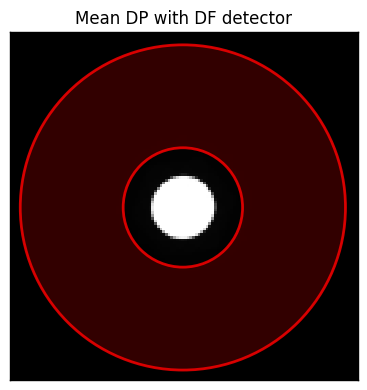

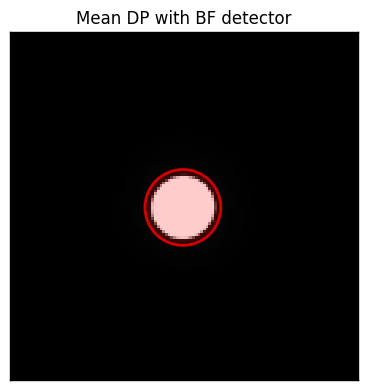

Dataset(shape=(128, 128), dtype=float32, name='BF')
  sampling: [0.429 0.429]
  units: ['A', 'A']
  signal units: 'arb. units'

In [7]:
dset.get_virtual_image(
    mode="annular",
    geometry=((probe_qy0, probe_qx0), (probe_R+10, probe_R*5)), 
    name="DF",
    show=True,
)

dset.get_virtual_image(
    mode="circle", 
    geometry=((probe_qy0, probe_qx0), probe_R+2), 
    name="BF",
    show=True,
)



(<Figure size 800x400 with 2 Axes>,
 array([<Axes: title={'center': 'DF'}>, <Axes: title={'center': 'BF'}>],
       dtype=object))

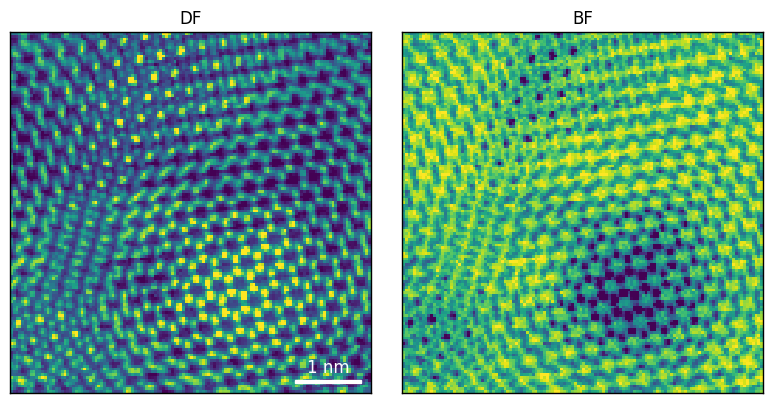

In [8]:
dset.show_virtual_images(cmap='viridis')

Forcing best fit rotation to 93 degrees.


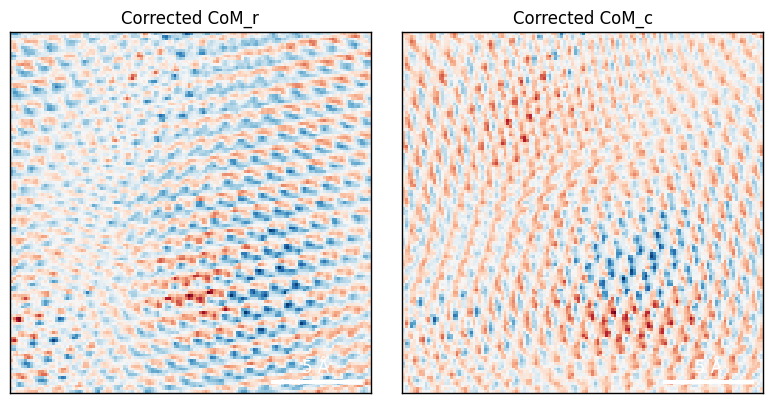

Normalizing intensities: 100%|██████████| 16384/16384 [00:09<00:00, 1784.95probe position/s]


In [9]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
    probe_energy=PROBE_ENERGY,
    force_com_rotation=93, 
)    

## Pixelated baseline reconstruction
We first run a pixelated model with identical slices to get a stable baseline before relaxing the model assumptions.

In [10]:
obj_model = ObjectPixelated.from_uniform(
    num_slices=NUM_SLICES, 
    slice_thicknesses=SLICE_THICKNESS, 
    obj_type='potential',
)

probe_model = ProbePixelated.from_params(
    num_probes=NUM_PROBES, 
    probe_params=probe_params,
)

detector_model = DetectorPixelated() 

ptycho_pix = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model,
    probe_model=probe_model,
    detector_model=detector_model,
    device='cpu',
)

ptycho_pix.preprocess( 
    obj_padding_px=(32,32),
    batch_size=128,
)

Iter 5/5, Loss: 2.153e+02: 100%|██████████| 5/5 [00:35<00:00,  7.10s/it]


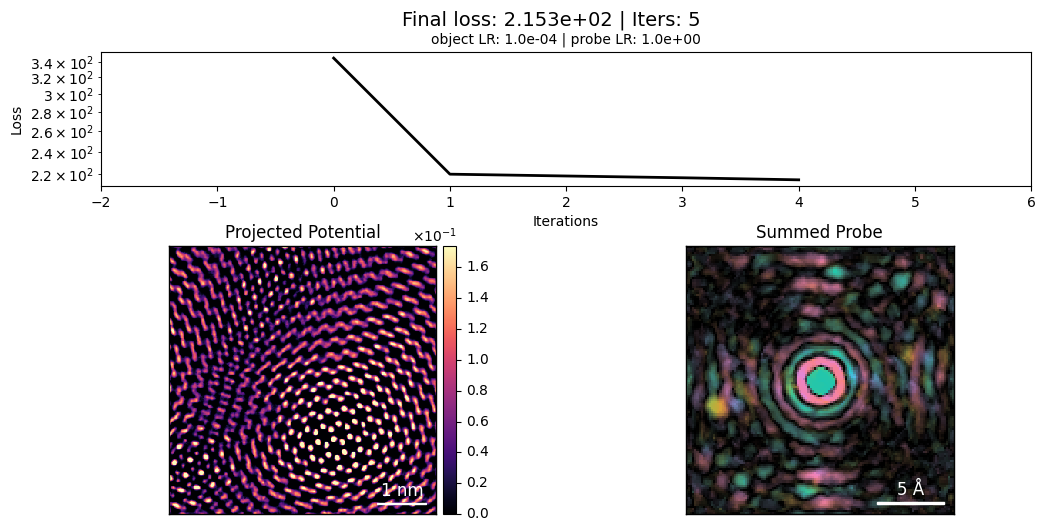

In [11]:
opt_params = { 
        "object": OptimizerParams.Adam(lr=1e-4),
        "probe": OptimizerParams.Adam(lr=1e0),
}

scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}

ptycho_pix.reconstruct(
    num_iters=5,
    reset=True,
    device='gpu',
    constraints={"object": PtychoObjConstraintParams.Raster(
        identical_slices=True,
        fix_potential_baseline=True,
        # positivity_mode="shrink", # clamp is the default, other option is "shrink",
        fix_potential_baseline_factor=0.75,  # Lower values relax the baseline constraint more.
    )},
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=128,
    store_snapshots_every=5,
).visualize()

  0%|          | 0/15 [00:00<?, ?it/s]

Iter 15/15, Loss: 1.962e+02: 100%|██████████| 15/15 [01:44<00:00,  6.98s/it]


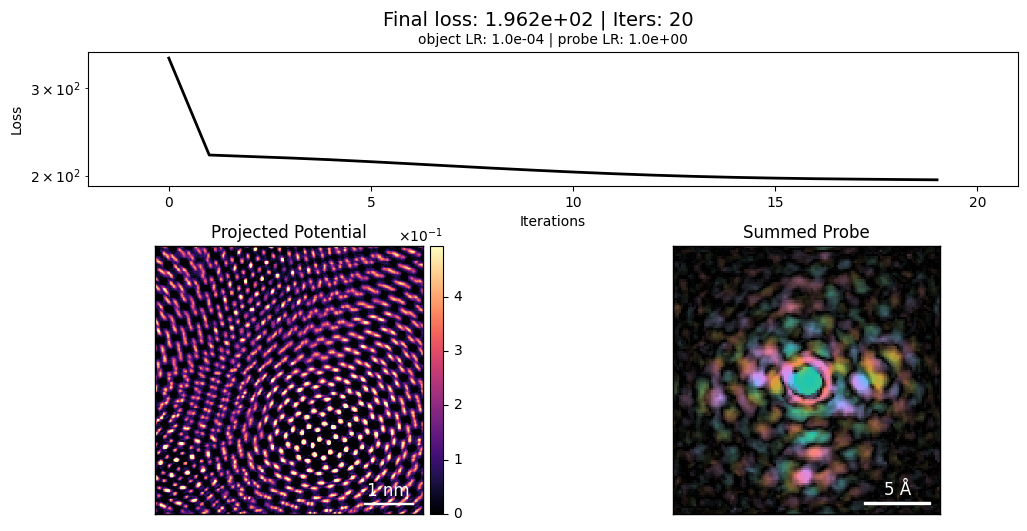

In [12]:
ptycho_pix.reconstruct(15).visualize()

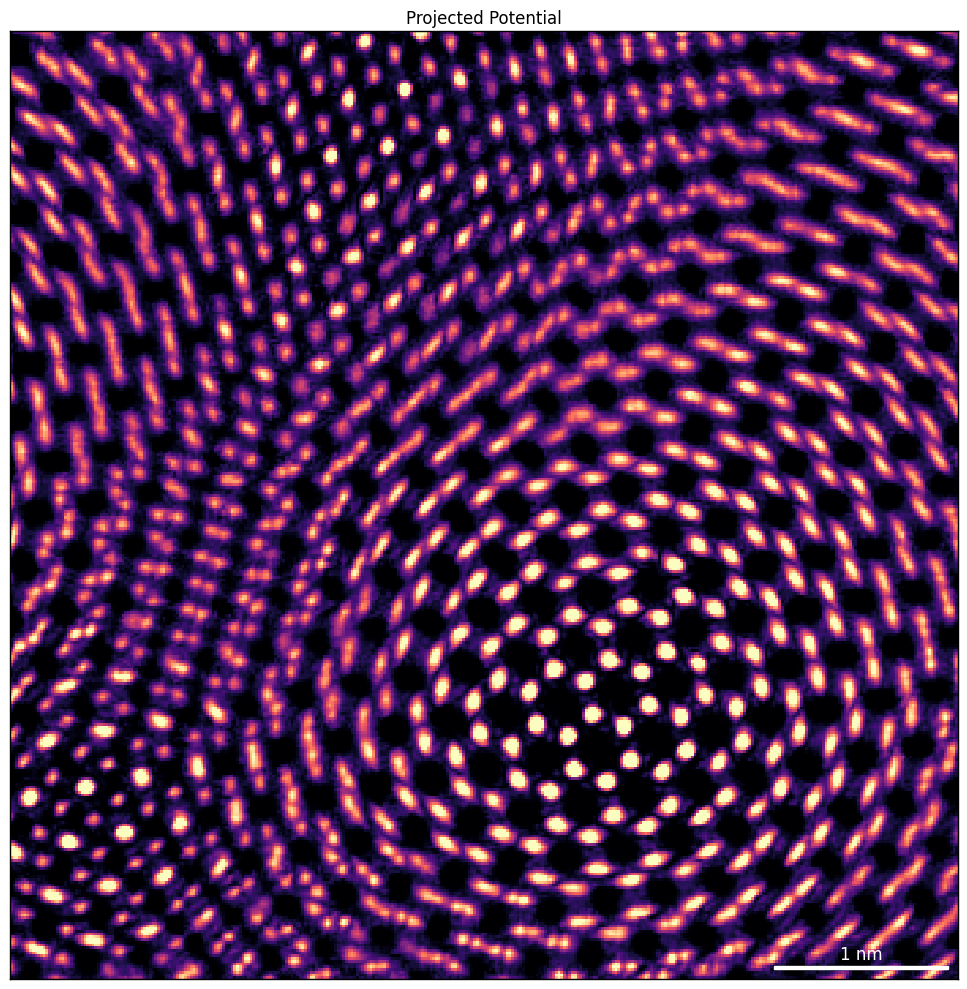

In [13]:
ptycho_pix.show_obj(axsize=(10,10))

## Pixelated free-slice reconstruction
For comparison, we release the identical-slice constraint and optimize independent slices in potential form.

Iter 5/5, Loss: 2.038e+02: 100%|██████████| 5/5 [00:34<00:00,  6.94s/it]


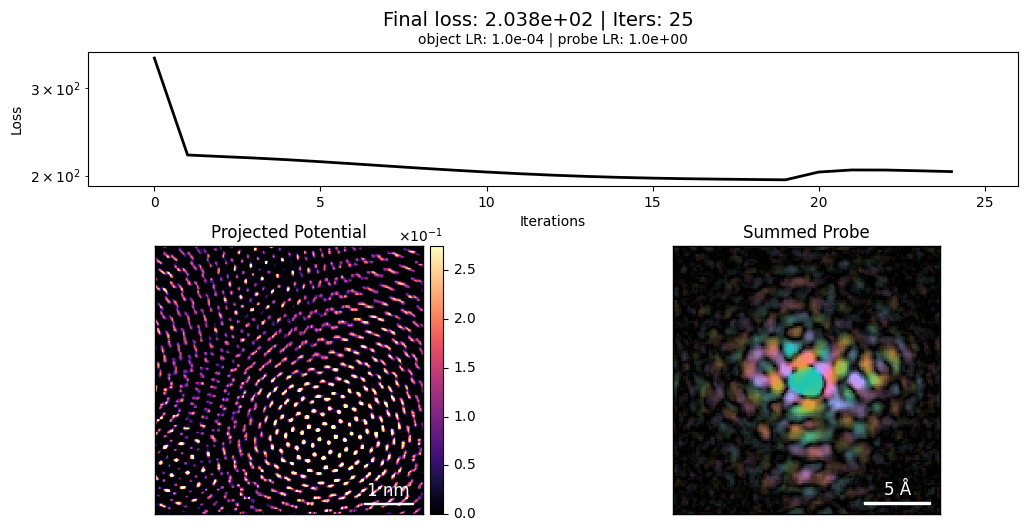

In [14]:
ptycho_pix_free = ptycho_pix.clone() 

opt_params = { 
        "object": OptimizerParams.Adam(lr=1e-4),
        "probe": OptimizerParams.Adam(lr=1e0),
}

scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}

ptycho_pix_free.reconstruct(
    num_iters=5,
    device="gpu",
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints={"object": PtychoObjConstraintParams.Raster(
        identical_slices=False,
        fix_potential_baseline=True,
        positivity_mode="shrink",
        fix_potential_baseline_factor=0.05, # could be better to go with less for more iterations, but this is faster
    )},
    batch_size=128,
    store_snapshots_every=5,
).visualize()

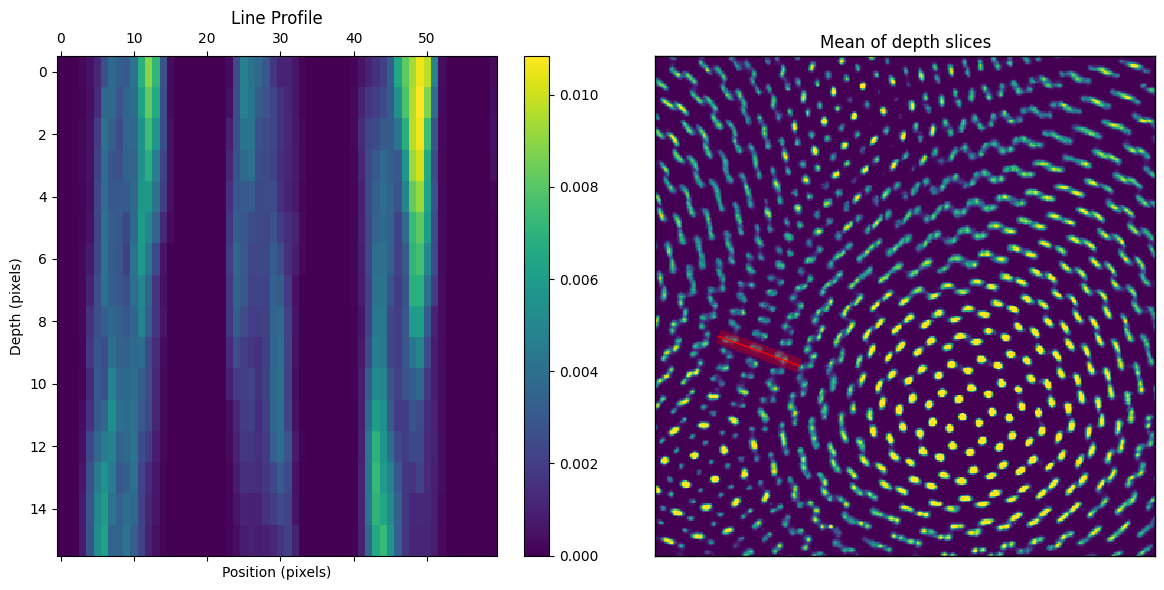

In [15]:
l_pix, prof_pix = linescan(ptycho_pix_free.obj_cropped, center=(205, 72), phi=20, line_len=60, show=True, linewidth=10, cmap='viridis')

## Deep image prior (DIP)
Next we switch the object model to DIP and compare behavior against the pixelated free-slice run.

The DIP run can be initialized from the pixelated free-slice result to reduce warm-up time and improve early stability.

  0%|          | 0/1500 [00:00<?, ?it/s]

Iter 1500/1500, Loss: 8.407e-06, : 100%|██████████| 1500/1500 [00:09<00:00, 150.84it/s]


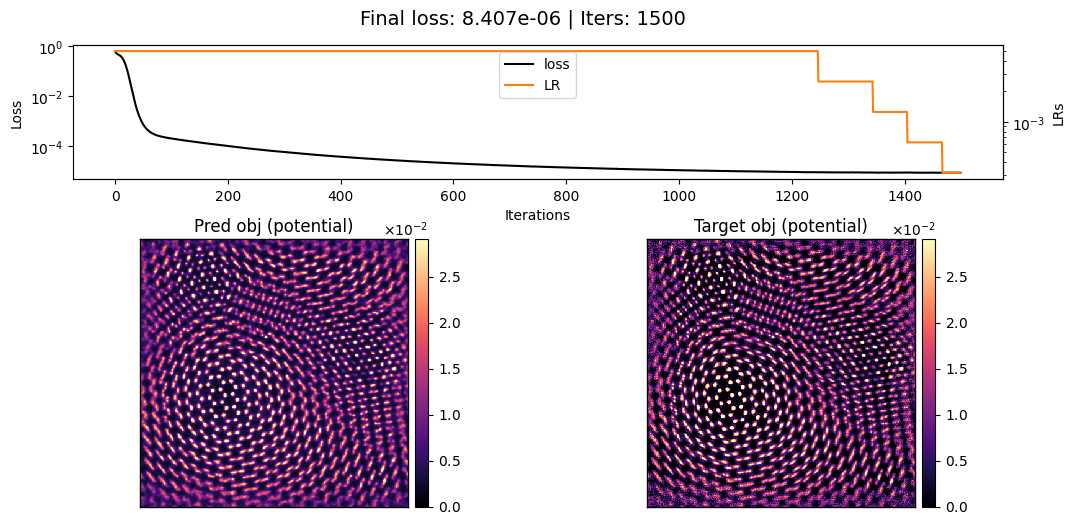

Iter 100/100, Loss: 2.469e+00, : 100%|██████████| 100/100 [00:01<00:00, 54.74it/s]


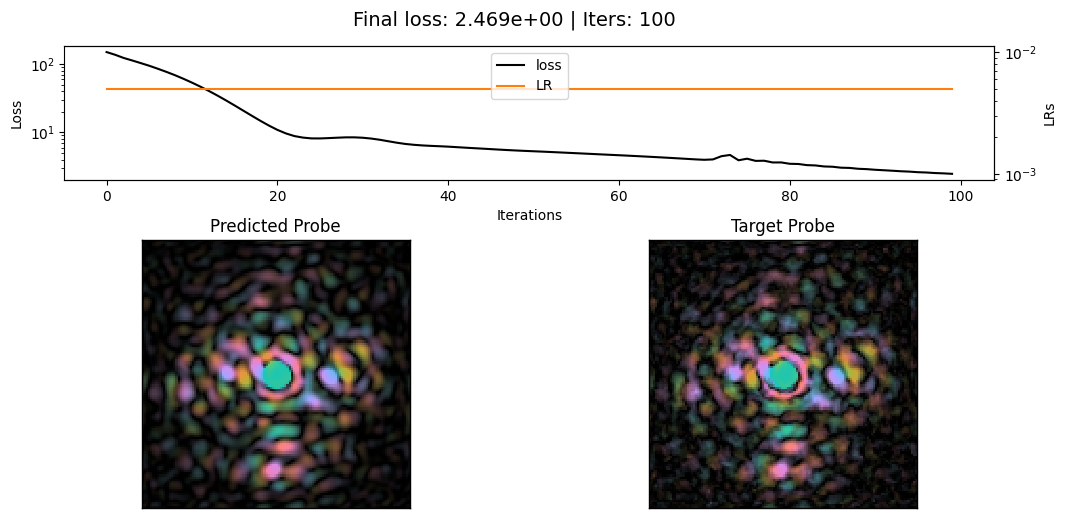

In [16]:
cnn_obj = CNN2d(
    in_channels = NUM_SLICES, 
    final_activation = "softplus", # not always a good idea because it makes model harder to train
)

obj_model_dip = ObjectDIP.from_pixelated(
    model=cnn_obj,
    pixelated=ptycho_pix.obj_model,
    device=config.get("device"),
)

cnn_probe = CNN2d(
    in_channels=NUM_PROBES,
    start_filters=32,
    dtype = torch.complex64,
)

probe_model_dip = ProbeDIP.from_pixelated(
    model=cnn_probe,
    pixelated=ptycho_pix.probe_model,
    device=config.get("device"),
)

# Pretrain enough so the subsequent free-slice optimization starts from a stable model.
obj_model_dip.pretrain(
    num_iters=1500,
    optimizer_params=OptimizerParams.Adam(lr=5e-3),
    scheduler_params=SchedulerParams.Plateau(),
)

probe_model_dip.pretrain(
    num_iters=100,
    optimizer_params=OptimizerParams.Adam(lr=5e-3),
    scheduler_params=SchedulerParams.Plateau(),
)

ptycho_dip = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_dip,
    probe_model=probe_model_dip,
    detector_model=detector_model,
    device="gpu",
)

ptycho_dip.preprocess(
    obj_padding_px=(32, 32),
)

Iter 5/5, Loss: 1.973e+02: 100%|██████████| 5/5 [00:50<00:00, 10.09s/it]


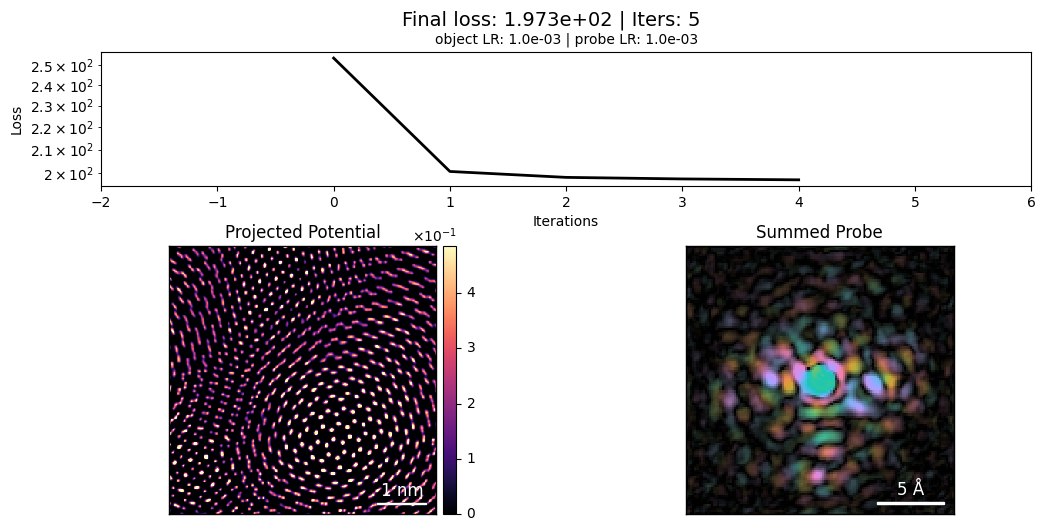

In [17]:
opt_params = {  
    "object": OptimizerParams.AdamW(lr=1e-3),
    "probe": OptimizerParams.AdamW(lr=1e-3),
}

scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}
ptycho_dip.reconstruct(
    num_iters=5,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints={"object": PtychoObjConstraintParams.Raster(
        identical_slices=True,
        fix_potential_baseline=True,
        fix_potential_baseline_factor=1, 
    )},
    batch_size=128,
    store_snapshots_every=1, 
).visualize()

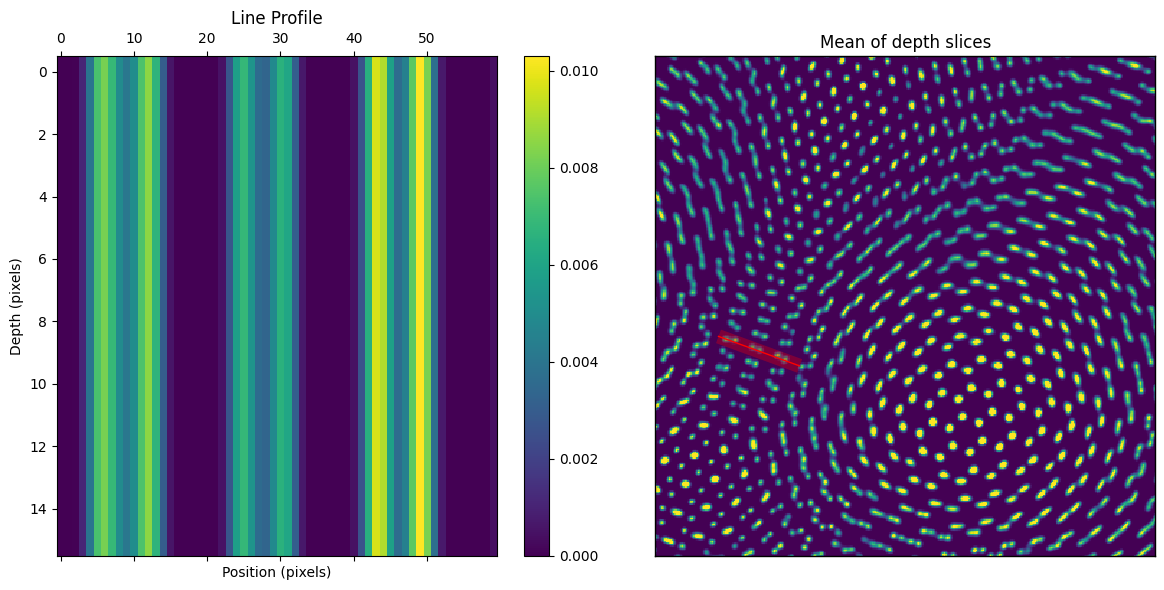

In [18]:
l_dip, prof_dip = linescan(ptycho_dip.obj_cropped, center=(205, 72), phi=20, line_len=60, show=True, linewidth=10, cmap='viridis')


Below we show one practical constraint configuration.
Other choices can also work, but this setup usually converges faster; very strong total-variation penalties can over-smooth atomic contrast.

In [19]:
# Logging helps compare loss terms and tune constraint weights.


Iter 10/10, Loss: 1.934e+02: 100%|██████████| 10/10 [01:47<00:00, 10.79s/it]


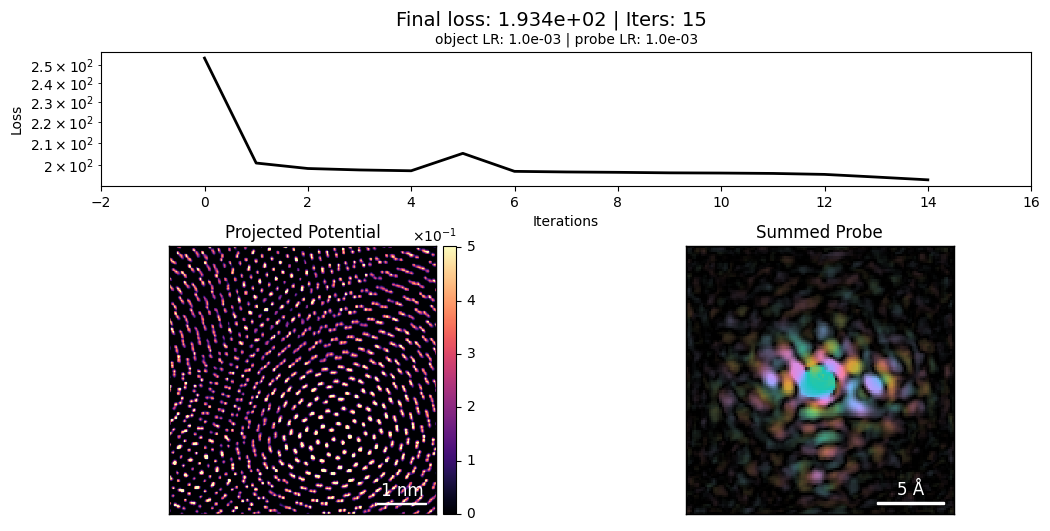

In [20]:
ptycho_dip_free = ptycho_dip.clone()
opt_params = {  
    "object": OptimizerParams.AdamW(lr=1e-3), # Use 1e-4 for a more conservative object update.
    "probe": OptimizerParams.AdamW(lr=1e-3), # Use 1e-4 for a more conservative probe update.
}
scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}

ptycho_dip_free.reconstruct(
    num_iters=10,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints={"object": PtychoObjConstraintParams.Raster(
        identical_slices=False,
        fix_potential_baseline=True,
        fix_potential_baseline_factor=1,  # Keep baseline anchored; lower values relax this.
        tv_weight_z= 5,  # Speeds convergence but too much can over-smooth along z.
        surface_zero_weight=10,  # Strongly encourages near-zero potential at slab surfaces.
    )},
    batch_size=128,
    device='gpu',
).visualize()

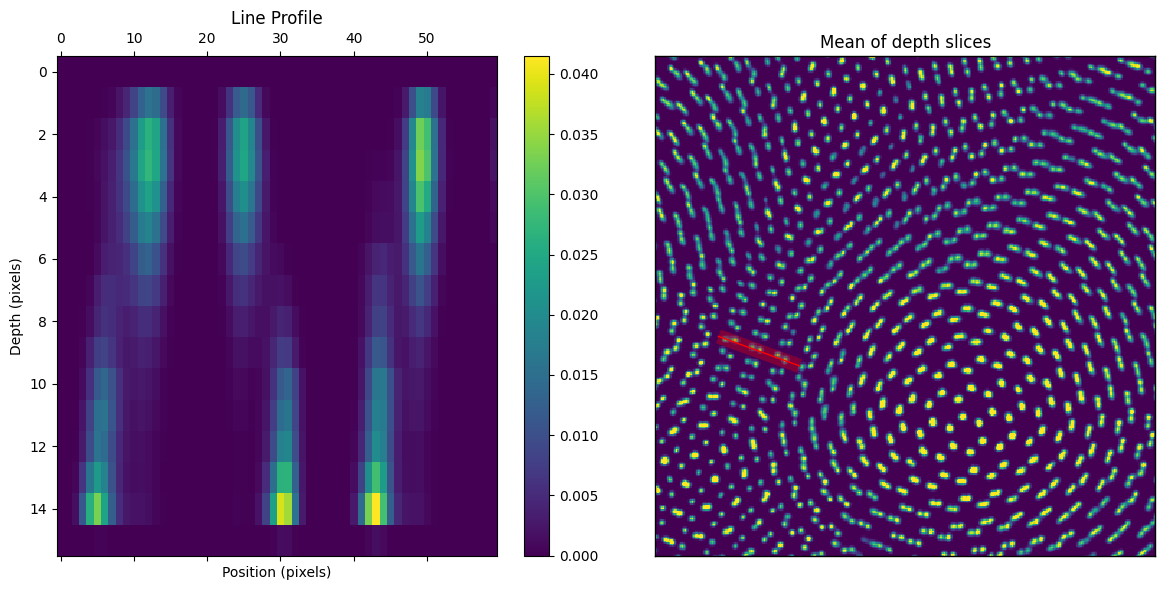

In [21]:
l_dip, prof_dip = linescan(ptycho_dip_free.obj_cropped, center=(205, 72), phi=20, line_len=60, show=True, linewidth=10, cmap='viridis')

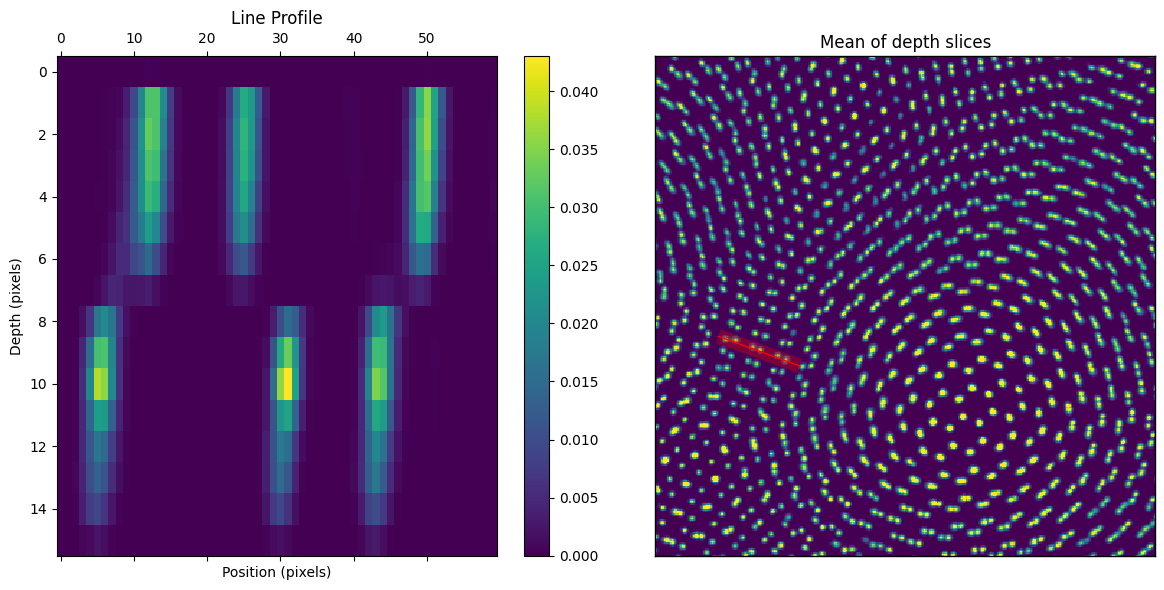

In [ ]:
l_dip, prof_dip = linescan(ptycho_dip_free.obj_cropped, center=(205, 72), phi=20, line_len=60, show=True, linewidth=10, cmap='viridis')

Iter 10/10, Loss: 1.895e+02: 100%|██████████| 10/10 [01:47<00:00, 10.79s/it]


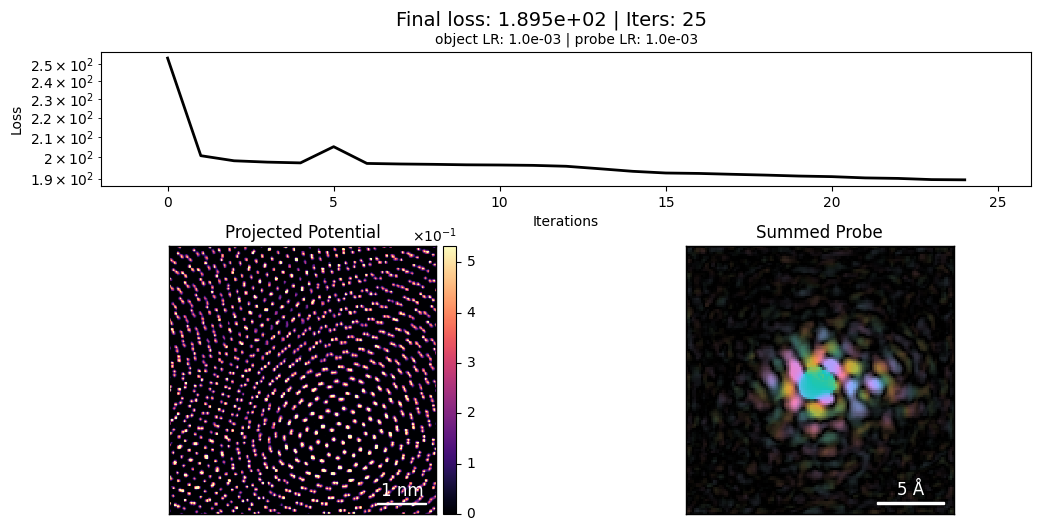

In [22]:
ptycho_dip_free.reconstruct(
    num_iters=10,
    store_snapshots_every=5,
).visualize()

(<Figure size 500x500 with 1 Axes>, <Axes: >)

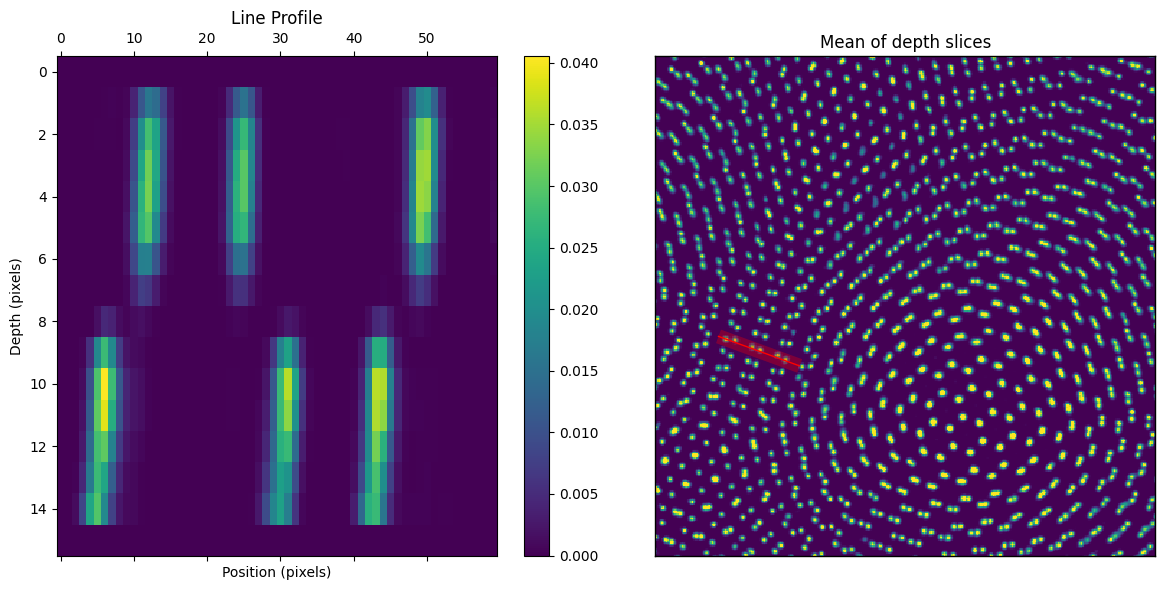

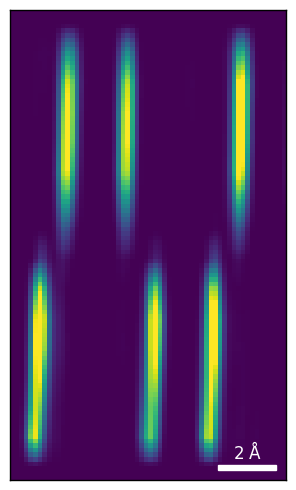

In [23]:
l_dip, prof_dip = linescan(ptycho_dip_free.obj_cropped, center=(205, 72), phi=20, line_len=60, show=True, linewidth=10, cmap='viridis')

rsc_fac_z = ptycho_dip_free.slice_thicknesses[0] / ptycho_dip_free.sampling[0] 

resampled_prof_dip: np.ndarray = skimage.transform.resize(
    prof_dip, 
    (prof_dip.shape[0] * rsc_fac_z, prof_dip.shape[1]),
    order=1,
    mode='edge',
)  # type: ignore

show_2d(
    resampled_prof_dip,
    cmap='viridis',
    axsize=(5,5),
    upper_quantile=0.98,
    lower_quantile=0.5,
    scalebar=[{"sampling": ptycho_dip_free.sampling[0], "units": r"$\mathrm{\AA}$"}],
)

(<Figure size 400x400 with 1 Axes>, <Axes: >)

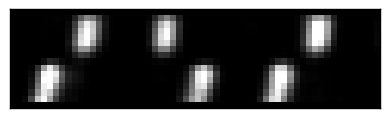

In [24]:
show_2d(prof_dip)